<a href="https://colab.research.google.com/github/moaaz-mohamedd/Autonomous-Vehicle-Perception-Module-Phase-2/blob/main/Part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 187M/187M [00:07<00:00, 23.9MB/s]



Training with StepLR
Epoch 1: Train 67.54% | Val 83.16%
Epoch 2: Train 97.12% | Val 92.83%
Epoch 3: Train 98.88% | Val 97.24%
Epoch 4: Train 99.25% | Val 97.22%
Epoch 5: Train 99.25% | Val 99.31%
Epoch 6: Train 99.97% | Val 99.77%
Epoch 7: Train 99.93% | Val 99.81%
Epoch 8: Train 100.00% | Val 99.83%
Epoch 9: Train 100.00% | Val 99.83%
Epoch 10: Train 100.00% | Val 99.87%

Training with CosineAnnealingLR
Epoch 1: Train 62.89% | Val 83.37%
Epoch 2: Train 96.16% | Val 94.97%
Epoch 3: Train 99.08% | Val 98.95%
Epoch 4: Train 99.30% | Val 98.67%
Epoch 5: Train 99.79% | Val 99.79%
Epoch 6: Train 99.97% | Val 99.87%
Epoch 7: Train 99.99% | Val 99.91%
Epoch 8: Train 100.00% | Val 99.85%
Epoch 9: Train 100.00% | Val 99.92%
Epoch 10: Train 100.00% | Val 99.94%


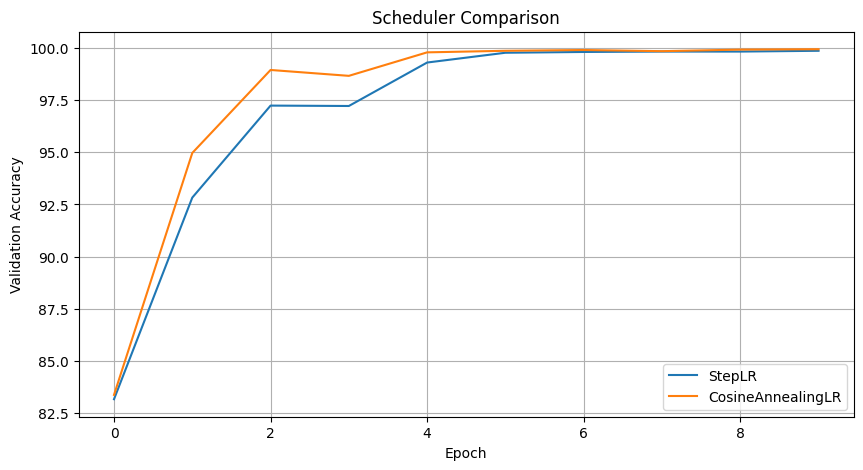

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214],
                         std=[0.2724, 0.2608, 0.2669])
])

full_dataset = datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2,2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

def train_model(model, optimizer, scheduler, epochs=10):
    criterion = nn.CrossEntropyLoss()
    history = {"train_acc":[], "val_acc":[]}

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

            _,pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()

        train_acc = 100. * correct / total

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                _,pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()

        val_acc = 100. * correct / total

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step()

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%")

    return history

model_step = TrafficSignCNN().to(device)
optimizer_step = optim.Adam(model_step.parameters(), lr=0.001)
scheduler_step = optim.lr_scheduler.StepLR(optimizer_step, step_size=5, gamma=0.5)

model_cosine = TrafficSignCNN().to(device)
optimizer_cosine = optim.Adam(model_cosine.parameters(), lr=0.001)
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer_cosine, T_max=10)

print("\nTraining with StepLR")
hist_step = train_model(model_step, optimizer_step, scheduler_step)

print("\nTraining with CosineAnnealingLR")
hist_cosine = train_model(model_cosine, optimizer_cosine, scheduler_cosine)

torch.save(model_cosine.state_dict(), "model.pth")

plt.figure(figsize=(10,5))
plt.plot(hist_step["val_acc"], label="StepLR")
plt.plot(hist_cosine["val_acc"], label="CosineAnnealingLR")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Scheduler Comparison")
plt.legend()
plt.grid()
plt.show()